In [79]:
# 1-D Double Integrator Problem
import numpy as np
import mosek.fusion as mf
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sys
from plot_ellipse import confidence_ellipse
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plotting
from numpy.random import default_rng
from scipy.io import loadmat # necessary to import the .mat file of the previous analysis


In [80]:
# The code below solves the problem of covariance steering and also mean control
# in the case where the final covariance is a pre-defined matrix (for chance constraint,
# namely a constraint that has to be satisfied with a certain probability, we need to rely
# to other algorithms.

In [81]:
# --------------------------
# Problem setup
# --------------------------
dt = 0.1 # length of each time step
n = 2  # state dimension
m = 1  # control dimension
N = 50  # number of nodes in the time grid
t = np.arange(N+1) * dt  # Time vector

rng = default_rng(1) # seed 1 for reproducibility
Nsamples = 1000

# Discrete-time double integrator
# All matrices are defined as a list of matrices (one for each time step, 0,1,..., N-1)
Am = [mf.Matrix.dense(np.array([[1, dt], [0, 1]])) for _ in range(N)]
Bm = [mf.Matrix.dense(np.array([[0], [dt]])) for _ in range(N)]
DmDmT = [mf.Matrix.dense(0.01 * np.eye(n)) for _ in range(N)]  # small process noise

# Cost matrices
Q_param = mf.Matrix.dense(np.eye(n))
R_param = mf.Matrix.dense(np.eye(m))

# Boundary conditions
Si = np.eye(n) * 0.7
Sf = np.array([[0.2, -0.1], [-0.1, 0.1]])
mu_i = np.zeros(n) # Vector (n,)=nx1
mu_f = np.array([2.0, 0.5])

In [82]:
# --------------------------
# 1. Mean Control Problem
# --------------------------
M_mean = mf.Model("mean_control")

# Variables
v = [M_mean.variable(f"v{k}", [m], mf.Domain.unbounded()) for k in range(N)]
V = [M_mean.variable(f"V{_k}", mf.Domain.inPSDCone(m)) for _k in range(N)]
mu = [M_mean.variable(f"mu{k}", [n], mf.Domain.unbounded()) for k in range(N + 1)]
Mmu = [M_mean.variable(f"Mmu{_k}", mf.Domain.inPSDCone(n)) for _k in range(N+1)]

J_mean = mf.Expr.constTerm(0.0)

for k in range(N):
    # Mean propagation
    M_mean.constraint(
        mf.Expr.sub(mu[k+1], mf.Expr.add(mf.Expr.mul(Am[k], mu[k]), mf.Expr.mul(Bm[k], v[k]))),
        mf.Domain.equalsTo(0.0)
    )
    
    # Relaxations
    PSD_block_v = mf.Expr.stack([[V[k], v[k]], [mf.Expr.transpose(v[k]), mf.Expr.constTerm(1.0)]])
    M_mean.constraint(PSD_block_v, mf.Domain.inPSDCone(m+1))
    
    PSD_block_mu = mf.Expr.stack([[Mmu[k], mu[k]], [mf.Expr.transpose(mu[k]), mf.Expr.constTerm(1.0)]])
    M_mean.constraint(PSD_block_mu, mf.Domain.inPSDCone(n+1))
    
    # Cost
    J_mean = mf.Expr.add(J_mean, mf.Expr.dot(R_param, V[k]))
    J_mean = mf.Expr.add(J_mean, mf.Expr.dot(Q_param, Mmu[k]))

# Boundary conditions
M_mean.constraint(mf.Expr.sub(mu[0], mf.Matrix.dense(mu_i[:, None])), mf.Domain.equalsTo(0.0))
M_mean.constraint(mf.Expr.sub(mu[N], mf.Matrix.dense(mu_f[:, None])), mf.Domain.equalsTo(0.0))

M_mean.objective(mf.ObjectiveSense.Minimize, J_mean)
M_mean.setLogHandler(sys.stdout)
M_mean.solve()
print("Mean Problem status:", M_mean.getProblemStatus())


Problem
  Name                   : mean_control    
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 104             
  Affine conic cons.     : 100 (450 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 153             
  Matrix variables       : 101 (scalarized: 203)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 99
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes

In [83]:
# --------------------------
# 2. Covariance Steering Problem
# --------------------------
M_cov = mf.Model("covariance_steering")

# Variables
Y = [M_cov.variable(f"Y{k}", mf.Domain.inPSDCone(m)) for k in range(N)]
U = [M_cov.variable(f"U{k}", [m, n], mf.Domain.unbounded()) for k in range(N)]
S = [M_cov.variable(f"S{k}", mf.Domain.inPSDCone(n)) for k in range(N + 1)]

J_cov = mf.Expr.constTerm(0.0)

for k in range(N):
    # Covariance propagation
    constr = mf.Expr.neg(S[k + 1])
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Am[k], S[k]), mf.Matrix.transpose(Am[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Bm[k], U[k]), mf.Matrix.transpose(Am[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Am[k], mf.Matrix.transpose(U[k])), mf.Matrix.transpose(Bm[k])))
    constr = mf.Expr.add(constr, mf.Expr.mul(mf.Expr.mul(Bm[k], Y[k]), mf.Matrix.transpose(Bm[k])))
    constr = mf.Expr.add(constr, DmDmT[k])
    M_cov.constraint(constr, mf.Domain.equalsTo(0.0))
    
    # LMI constraint
    X = mf.Expr.stack([[S[k], mf.Expr.transpose(U[k])], [U[k], Y[k]]])
    M_cov.constraint(X, mf.Domain.inPSDCone(n + m))
    
    # Cost
    J_cov = mf.Expr.add(J_cov, mf.Expr.dot(Q_param, S[k]))
    J_cov = mf.Expr.add(J_cov, mf.Expr.dot(R_param, Y[k]))

# Boundary conditions
M_cov.constraint(mf.Expr.sub(S[0], mf.Matrix.dense(Si)), mf.Domain.equalsTo(0.0))
M_cov.constraint(mf.Expr.sub(S[N], mf.Matrix.dense(Sf)), mf.Domain.equalsTo(0.0))

M_cov.objective(mf.ObjectiveSense.Minimize, J_cov)
M_cov.setLogHandler(sys.stdout)
M_cov.solve()
print("Covariance Problem status:", M_cov.getProblemStatus())


Problem
  Name                   : covariance_steering
  Objective sense        : minimize        
  Type                   : CONIC (conic optimization problem)
  Constraints            : 208             
  Affine conic cons.     : 50 (300 rows)
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 101             
  Matrix variables       : 101 (scalarized: 203)
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 1                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes              : 1               
Lin. dep.  - dual attempts          : 0      

In [84]:
# Optimization solved in the previous two cells (split into Mean and Covariance problems)


In [85]:
# --------------------------
# Extract and process results
# --------------------------
mu_opt = []
S_opt = []

for k in range(N + 1):
    mu_k = mu[k].level()
    mu_opt.append(np.array(mu_k))

    S_k_flat = S[k].level()
    S_k_reshaped = np.array(S_k_flat).reshape((n, n))
    S_opt.append(S_k_reshaped)

# Convert mu_opt to shape (N+1, n)
mu_array = np.array([np.ravel(mu) for mu in mu_opt])  # shape (N+1, 2) since n=2 (2 states pos, vel)
# Extract optimal mean controls v_opt as numpy array shape (N, m)
v_opt = np.array([np.ravel(vk.level()) for vk in v])  # shape (N, m)
# If m = 1 you'll get shape (N,1). For convenience make it (N,) in that case:
if v_opt.shape[1] == 1:
    v_opt = v_opt.ravel()   # shape (N,)

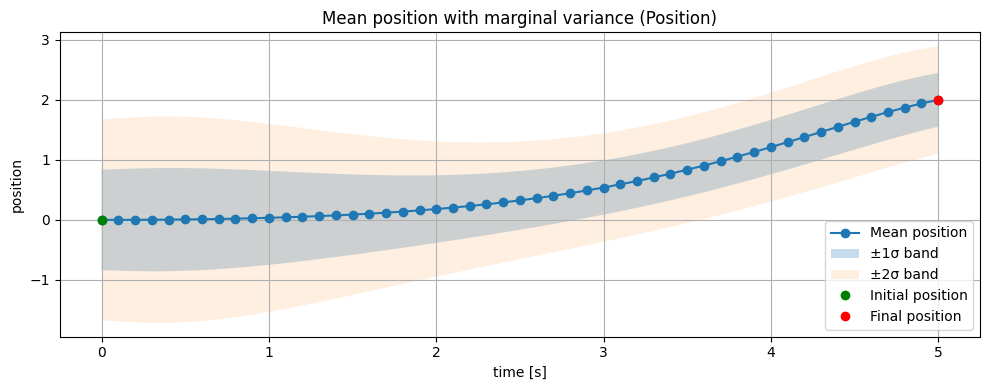

In [86]:
# --------------------------
# Plot 1: Pos. Mean trajectory
# --------------------------

# Convert S_opt into a list of nxn numpy arrays, and extract position variance
S_arr = [np.array(Sk).reshape((n, n)) for Sk in S_opt]
pos_var = np.array([Sk[0, 0] for Sk in S_arr])

# Guard against tiny negative values due to numerical issues
pos_var = np.clip(pos_var, a_min=0.0, a_max=None)
pos_std = np.sqrt(pos_var)

# --- Plot position vs time with ±1σ and ±2σ bands ---
fig1, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, mu_array[:, 0], marker='o', linestyle='-', label='Mean position')
ax.fill_between(t, mu_array[:, 0] - pos_std, mu_array[:, 0] + pos_std,
                alpha=0.25, label='±1σ band')
ax.fill_between(t, mu_array[:, 0] - 2*pos_std, mu_array[:, 0] + 2*pos_std,
                alpha=0.12, label='±2σ band')

# Mark initial and final
ax.plot(t[0], mu_array[0, 0], 'go', label='Initial position')
ax.plot(t[-1], mu_array[-1, 0], 'ro', label='Final position')

ax.set_xlabel('time [s]')
ax.set_ylabel('position')
ax.set_title('Mean position with marginal variance (Position)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

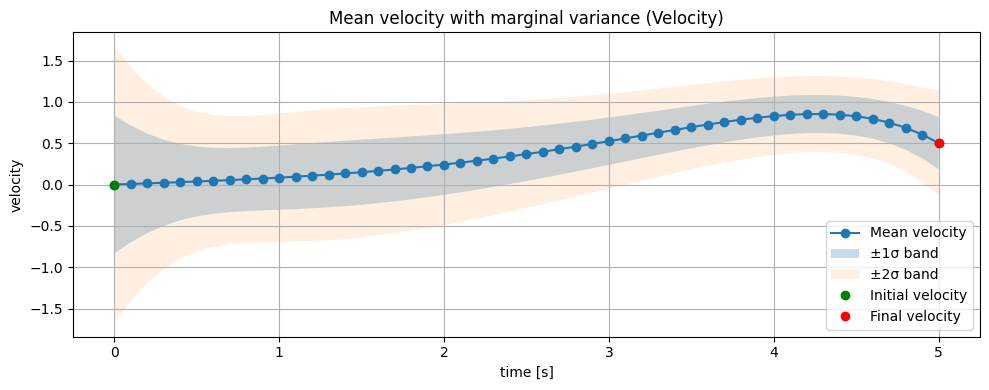

In [87]:
# --------------------------
# Plot 2: Vel. Mean trajectory
# --------------------------

# Convert S_opt into a list of nxn numpy arrays, and extract velocity variance
S_arr = [np.array(Sk).reshape((n, n)) for Sk in S_opt]
vel_var = np.array([Sk[1, 1] for Sk in S_arr])

# Guard against tiny negative values due to numerical issues
vel_var = np.clip(vel_var, a_min=0.0, a_max=None)
vel_std = np.sqrt(vel_var)

# --- Plot velocity vs time with ±1σ and ±2σ bands ---
fig2, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, mu_array[:, 1], marker='o', linestyle='-', label='Mean velocity')
ax.fill_between(t, mu_array[:, 1] - vel_std, mu_array[:, 1] + vel_std,
                alpha=0.25, label='±1σ band')
ax.fill_between(t, mu_array[:, 1] - 2*vel_std, mu_array[:, 1] + 2*vel_std,
                alpha=0.12, label='±2σ band')

# Mark initial and final
ax.plot(t[0], mu_array[0, 1], 'go', label='Initial velocity')
ax.plot(t[-1], mu_array[-1, 1], 'ro', label='Final velocity')

ax.set_xlabel('time [s]')
ax.set_ylabel('velocity')
ax.set_title('Mean velocity with marginal variance (Velocity)')
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

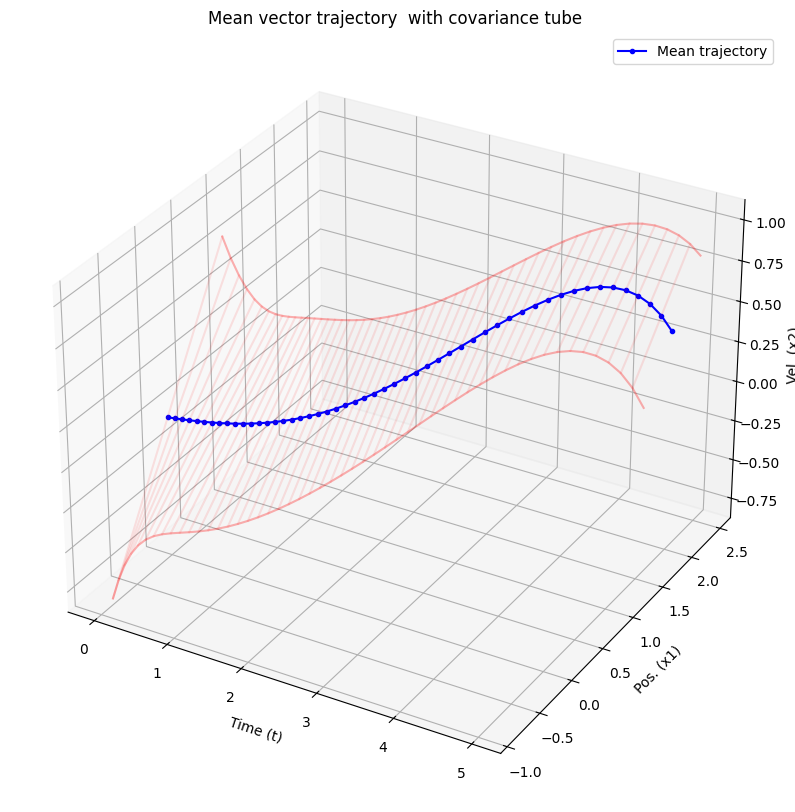

In [88]:
# --------------------------
# Plot 3: 3D Tube Plot
# --------------------------
sigma_mult = 1.0  # 1-sigma tube (~68% confidence), 2.0 = 2-sigma (~95%)
upper_bound = mu_array + sigma_mult * np.array([np.sqrt(np.diag(S)) for S in S_opt])
lower_bound = mu_array - sigma_mult * np.array([np.sqrt(np.diag(S)) for S in S_opt])

fig3 = plt.figure(figsize=(10,10))
ax = fig3.add_subplot(111, projection='3d')

# Plot mean trajectory (Both for position and velocity)
ax.plot(t, mu_array[:,0], mu_array[:,1], 'b.-', label='Mean trajectory')

# Plot “tube” by plotting lines for upper and lower bounds
ax.plot(t, upper_bound[:,0], upper_bound[:,1], color='r', alpha=0.3)
ax.plot(t, lower_bound[:,0], lower_bound[:,1], color='r', alpha=0.3)

# Fill between (rough approximation)
for k in range(N):
    ax.plot([t[k], t[k]],
            [lower_bound[k,0], upper_bound[k,0]],
            [lower_bound[k,1], upper_bound[k,1]],
            color='r', alpha=0.1)

# Labels
ax.set_xlabel("Time (t)")
ax.set_ylabel("Pos. (x1)")
ax.set_zlabel("Vel. (x2)")
ax.set_title("Mean vector trajectory  with covariance tube")
ax.legend()
plt.show()

mc P [[[ 0.69742488 -0.02601092]
  [-0.02601092  0.7224781 ]]

 [[ 0.70553536  0.05073962]
  [ 0.05073962  0.72694478]]

 [[ 0.73082061  0.12814301]
  [ 0.12814301  0.73766523]]

 [[ 0.76532904  0.19835959]
  [ 0.19835959  0.74637353]]

 [[ 0.82949109  0.27603279]
  [ 0.27603279  0.76998449]]

 [[ 0.91100509  0.35467522]
  [ 0.35467522  0.78747756]]

 [[ 0.99595877  0.4363453 ]
  [ 0.4363453   0.8012158 ]]

 [[ 1.09798281  0.51625246]
  [ 0.51625246  0.81076144]]

 [[ 1.22045137  0.60387975]
  [ 0.60387975  0.82848217]]

 [[ 1.35704746  0.68373684]
  [ 0.68373684  0.84267563]]

 [[ 1.51370797  0.7695935 ]
  [ 0.7695935   0.85147022]]

 [[ 1.66449635  0.84887098]
  [ 0.84887098  0.86474517]]

 [[ 1.85150897  0.9324078 ]
  [ 0.9324078   0.87042625]]

 [[ 2.05684225  1.02652457]
  [ 1.02652457  0.8863814 ]]

 [[ 2.28314905  1.11364877]
  [ 1.11364877  0.89225102]]

 [[ 2.53081884  1.20294128]
  [ 1.20294128  0.89898637]]

 [[ 2.7892737   1.29218289]
  [ 1.29218289  0.90700132]]

 [[ 3.068

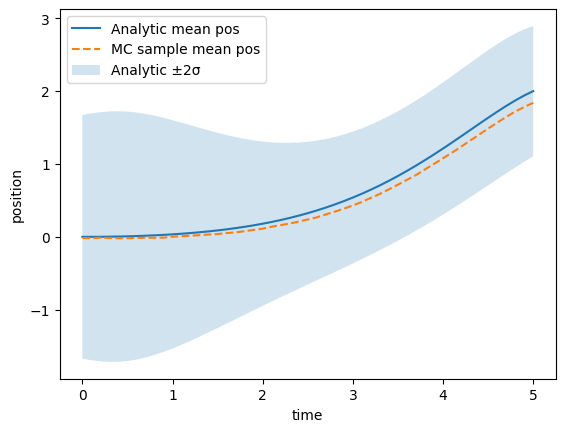

In [89]:
# --------------------------
# Monte Carlo simulation
# --------------------------

# Matrices in numpy format
A_np = np.array([[1.0, dt],[0.0, 1.0]])
B_np = np.array([[0.0],[dt]])
W_np = 0.01 * np.eye(n)

# Draw initial samples: X shape (Nsamples, n)
X = rng.multivariate_normal(mean=mu_i, cov=Si, size=Nsamples)

# Preallocate arrays to store MC means and covariances at every timestep
mc_mu = np.zeros((N+1, n))
mc_P = np.zeros((N+1, n, n))

# record initial sample statistics
mc_mu[0] = X.mean(axis=0)
mc_P[0] = np.cov(X, rowvar=False, bias=False)  # unbiased sample covariance

# propagate each time step using optimized mean controls v_opt and process noise W_np
for k in range(N):
    # process noise for each sample: shape (Nsamples, n)
    W = rng.multivariate_normal(mean=np.zeros(n), cov=W_np, size=Nsamples)

    # control for this step u_k (if m==1 this is scalar)
    u_k = v_opt[k]   # shape () or (m,)

    # control contribution: shape (n,) (broadcasted later)
    control_term = (B_np @ np.atleast_1d(u_k)).reshape((n,))

    # propagate all samples vectorized:
    # X_{k+1} = A X_k + B u_k + w_k
    # note: X @ A_np.T does (Nsamples, n)
    X = X @ A_np.T + control_term + W

    # save MC moments
    mc_mu[k+1] = X.mean(axis=0)
    mc_P[k+1] = np.cov(X, rowvar=False, bias=False)

# example overlay for position mean (position = state index 0)
plt.figure()
plt.plot(t, mu_array[:,0], label='Analytic mean pos')
plt.plot(t, mc_mu[:,0], '--', label='MC sample mean pos')
sigma_pos = np.sqrt([S_opt[k][0,0] for k in range(N+1)])  # analytic std
plt.fill_between(t, mu_array[:,0]-2*sigma_pos, mu_array[:,0]+2*sigma_pos, alpha=0.2, label='Analytic ±2σ')
print("mc P", mc_P)
plt.legend(); plt.xlabel('time'); plt.ylabel('position'); plt.show()



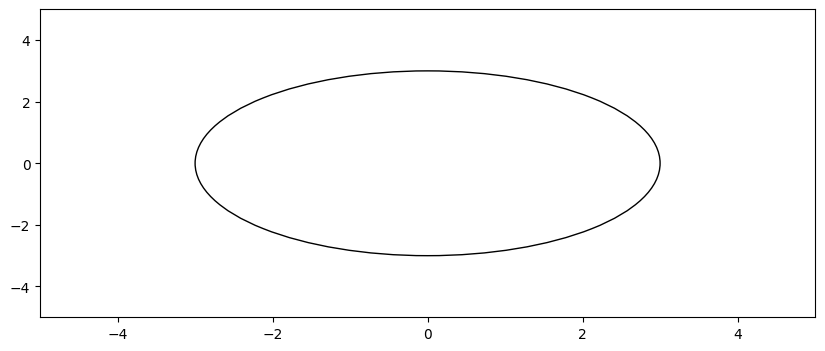

In [90]:
# plot different trajetories
from plot_ellipse import *
fig4, ax = plt.subplots(figsize=(10,4))
confidence_ellipse(ax, np.eye(2), mean=np.zeros(2), n_std=3.0)
ax.set_xlim([-5,5])
ax.set_ylim([-5,5])
plt.show()